# HistoMap Tutorial: Advanced Analysis with Tissue Annotations

## Introduction

In this advanced tutorial, we explore how to leverage tissue annotations in spatial transcriptomics data for sophisticated analyses of gene expression patterns across tissue regions. Spatial relationships between different tissue components - such as tumor-stroma interfaces or distance gradients from specific structures - often contain valuable biological information about tumor microenvironments and cellular interactions.

After creating annotation maps in the previous tutorial, we'll now use these maps to:

1. Calculate and visualize distances from specific tissue regions
2. Analyze gene expression patterns relative to these distances
3. Identify genes with specific spatial expression trends
4. Characterize tissue interfaces and boundary regions

This type of analysis can reveal:

- Gradients of gene expression extending from specific tissue boundaries
- Genes involved in cross-talk between different tissue compartments
- Potential cell-cell communication patterns
- Spatial organization of microenvironmental features

Let's begin by loading our previously annotated HistoMap object.

## 1. Setting up the Environment

First, we'll import the necessary libraries and load our previously saved HistoMap object that contains both gene expression data and tissue annotations.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import HistoMapTx as hm  # Main package for annotation integration
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set plot style and figure size for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 10]

# Load the previously processed HistoMap object
histomap = hm.load_histomap("histomap_filtered_annotated_pickle")
print(histomap) 

Object loaded from histomap_filtered_annotated_pickle
HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff
🔢 Number of annotations present: 6
🏷 Annotations: giant_cells, Necrosis, Tumor, Stroma, Negative, Positive
🏷 Activated annotations: Necrosis, giant_cells, Stroma, Tumor
🏷 Disabled annotations: Positive, Negative

-------Spatial Data--------
SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2773, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2773, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 

### 1.1 Reviewing the Annotation Map

Let's first review our annotation map to remind ourselves of the spatial organization of the different tissue regions in our sample.

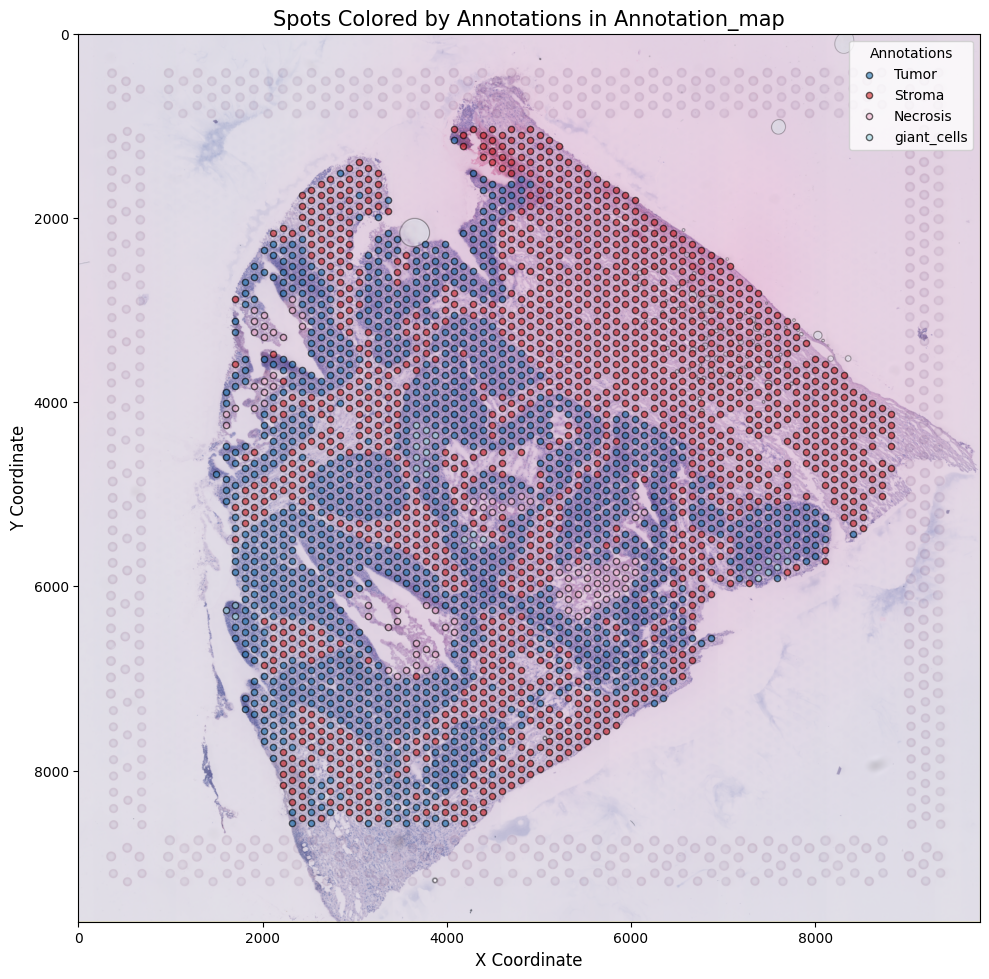

In [4]:
# Display the annotation map we created in the previous tutorial
# This shows each Visium spot colored according to its assigned tissue annotation
hm.plot_annotation_map(histomap)

## 2. Spatial Distance Analysis

One of the most powerful aspects of spatial transcriptomics is the ability to analyze how gene expression changes with distance from specific tissue regions. This can reveal gradients of signaling molecules, spatial organization of immune responses, and other distance-dependent biological phenomena.

### 2.1 Computing Distances from Specific Tissue Regions

We'll start by calculating the distance from each spot to the nearest spot annotated as 'Tumor'. This creates a continuous spatial variable that we can use to analyze expression patterns.

In [5]:
# Calculate the distance from each spot to the nearest spot annotated as 'Tumor'
# This function adds a new column to the spot metadata named 'distance_to_Tumor'
# Distances are in the same units as the spot coordinates (typically microns)
hm.compute_nearest_annotation_distance(histomap, 'Tumor')

### 2.2 Visualizing Distance Gradients

Now let's visualize these distances as a spatial heatmap overlaid on the tissue. This shows us the distance gradient extending outward from the tumor regions.

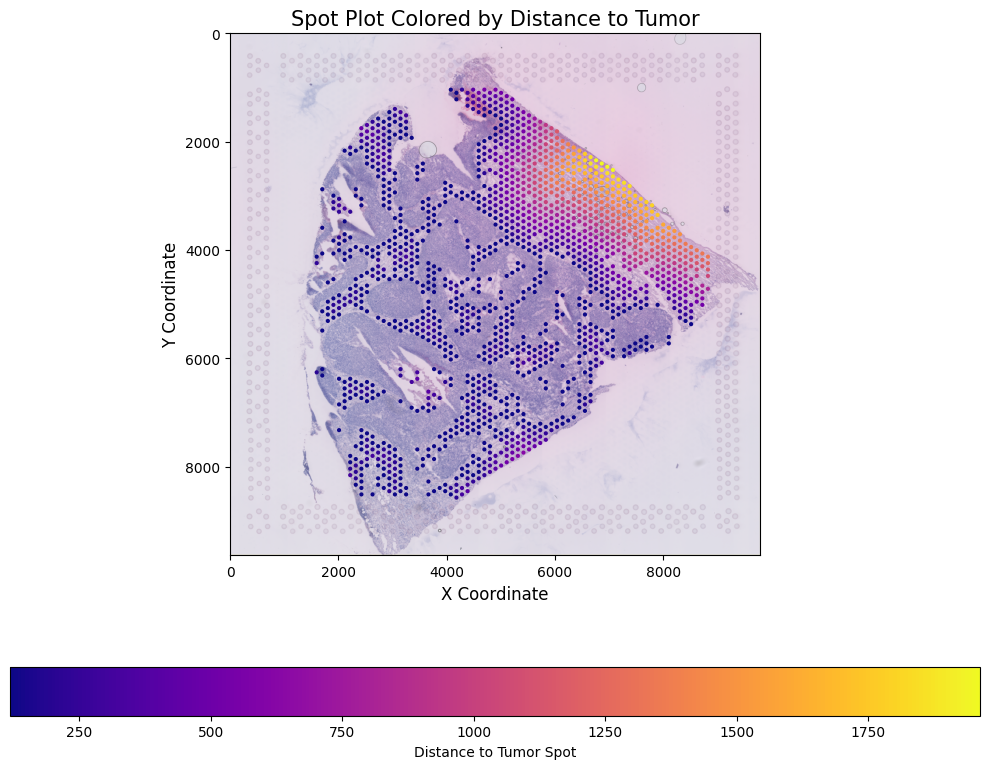

In [6]:
# Plot the distances as a heatmap, where darker colors represent spots closer to the tumor
# and lighter colors represent spots farther away
hm.plot_distance_overlay(histomap, 'Tumor')

### 2.3 Computing Distances from Multiple Tissue Regions

We can repeat this process for other tissue regions of interest. Let's calculate distances from 'Stroma' regions, which often form the supporting framework for tumors and contain important immune and structural cells.

In [7]:
# Calculate distances from 'Stroma' regions
# This adds a new column 'distance_to_Stroma' to the spot metadata
hm.compute_nearest_annotation_distance(histomap, 'Stroma')

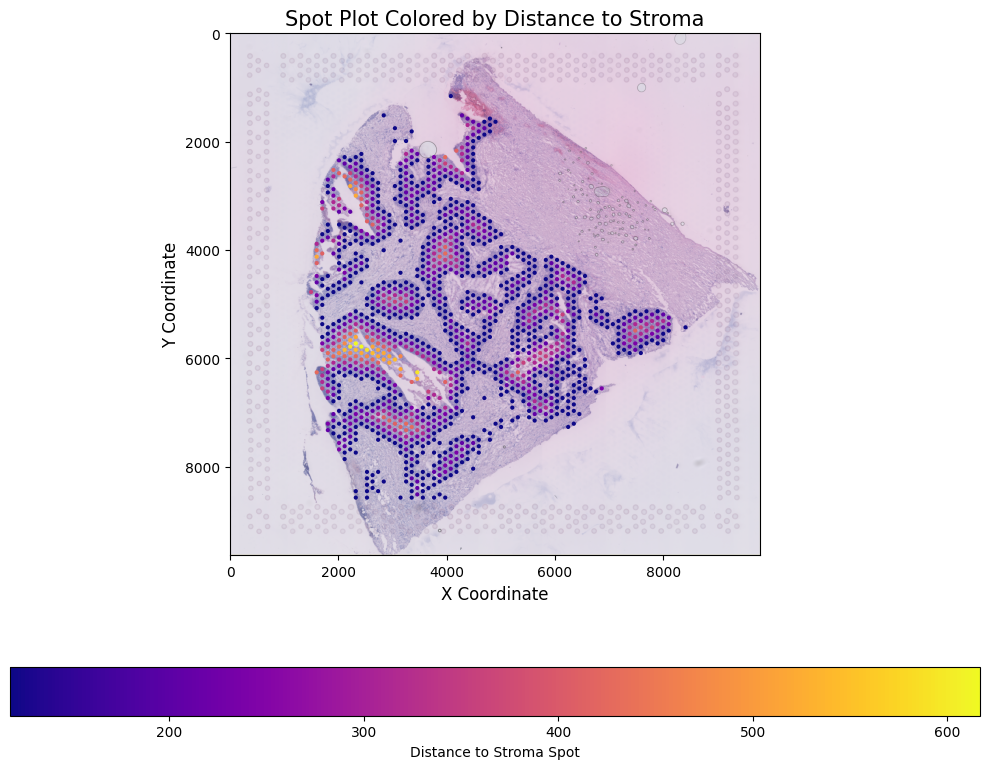

In [8]:
# Visualize the distance gradient from stroma regions
hm.plot_distance_overlay(histomap, 'Stroma')

## 3. Gene Expression Analysis Relative to Spatial Distances

Now that we have calculated distances from key tissue regions, we can analyze how gene expression varies with these distances. This can reveal genes that are differentially expressed at specific distances from tissue boundaries.

### 3.1 Visualizing Gene Expression vs. Distance

Let's examine how the expression of selected genes changes with distance from the tumor region. We'll look at genes that might be involved in different aspects of the tumor microenvironment:

- **MT-ND2**: A mitochondrial gene that might reflect metabolic changes
- **VIM**: Vimentin, a marker of mesenchymal cells and epithelial-to-mesenchymal transition
- **PECAM1**: A marker of endothelial cells and vascular structures
- **COL1A2**: Collagen type I, a marker of extracellular matrix and fibroblast activity

<Figure size 1000x500 with 0 Axes>

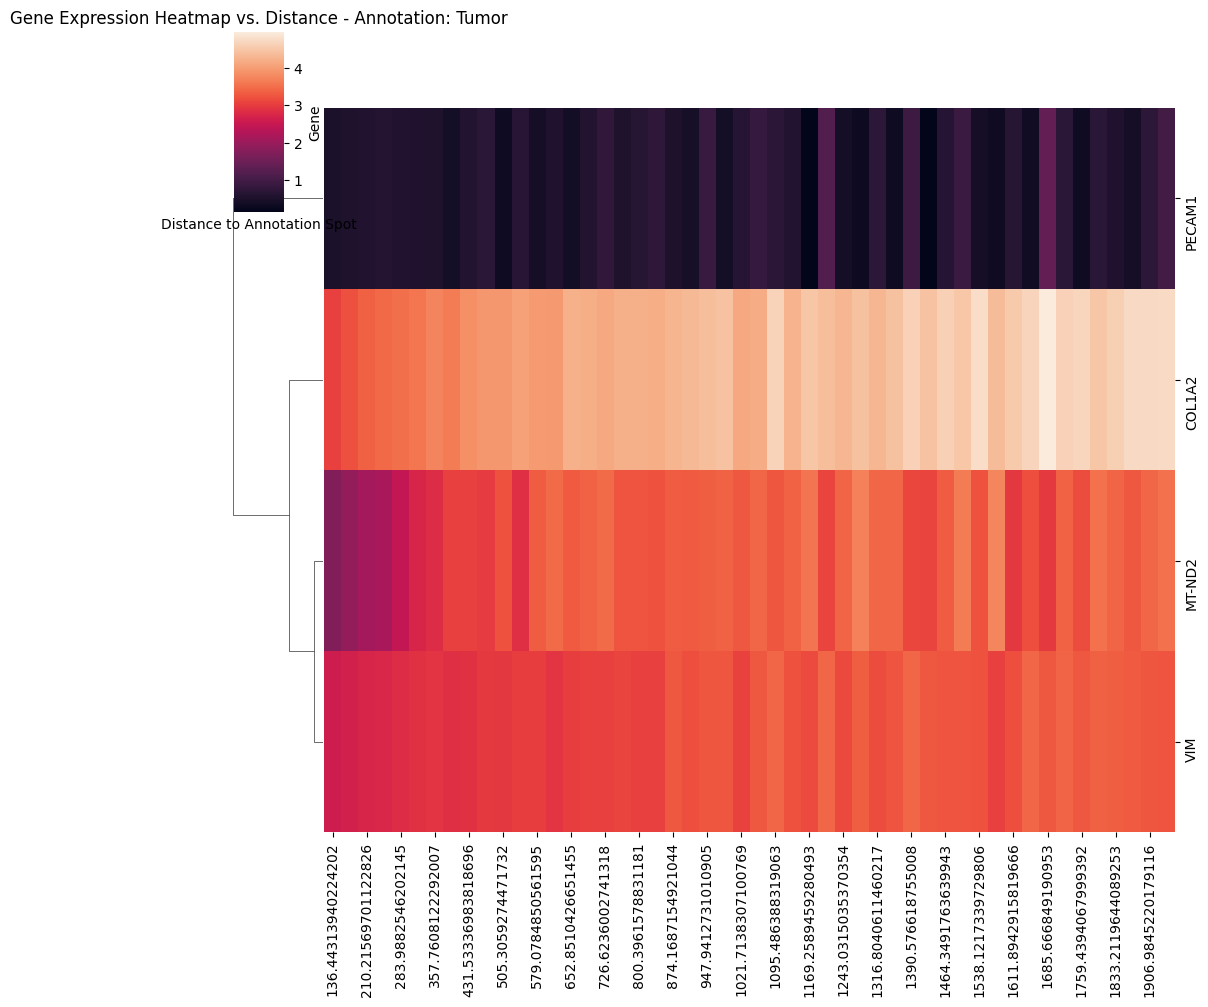

In [10]:
# Plot gene expression vs. distance from tumor for selected genes
# Parameters:
# - genes: List of gene symbols to analyze
# - annotation: The reference tissue annotation for distance calculation
# - bins: Number of distance bins to create for smoothing
# - interpolate: Whether to interpolate between bins for smoother visualization
# - normalize: Scale expression values within each gene (0-1) for better comparison
# - log1p: Apply log1p transformation to expression values (recommended for count data)
hm.plot_gene_expression_distance_heatmap(histomap, 
                                         genes=['MT-ND2', 'VIM', 'PECAM1', 'COL1A2'], 
                                         annotation="Tumor", 
                                         bins=50, 
                                         interpolate=True, 
                                         normalize=True, 
                                         log1p=True)

### 3.2 Identifying Genes with Spatial Expression Patterns

Now, let's take a more systematic approach by identifying genes that show distinct expression patterns relative to distance from the tumor. This can reveal groups of genes that are co-regulated in specific spatial contexts.

We'll use clustering to group genes with similar spatial expression patterns.

Get variable genes.
Compute trends according to the distance for the variable genes


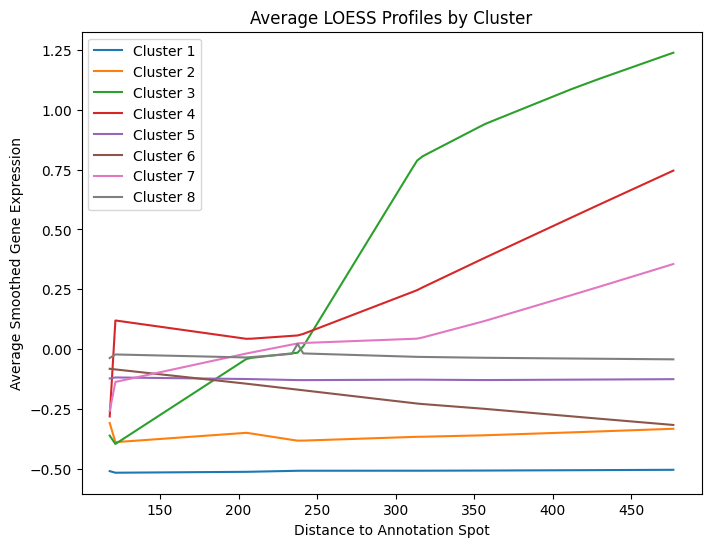

In [12]:
# Identify genes with distinct spatial expression patterns
# Parameters explained:
# - "Tumor": The reference annotation for distance calculation
# - max_distance: Maximum distance (in microns) to consider
# - n_top_genes: Number of highly variable genes to include in the analysis
# - ncluster: Number of gene clusters to identify
# - plot_trend_per_cluster: Whether to plot the average trend for each cluster

# This returns a DataFrame with gene symbols and their assigned clusters
cluster_df = hm.identify_gene_distance_trend(histomap, 
                                            "Tumor", 
                                            max_distance=500, 
                                            n_top_genes=500, 
                                            ncluster=10, 
                                            plot_trend_per_cluster=True)

### 3.3 Examining Gene Cluster Distribution

Let's look at how many genes were assigned to each cluster. This gives us an idea of how common different spatial expression patterns are.

In [13]:
# Count the number of genes in each cluster
cluster_counts = cluster_df['Cluster'].value_counts()
print("Number of genes in each spatial expression cluster:")
cluster_counts

Number of genes in each spatial expression cluster:


Cluster
8    251
5     69
2     60
1     37
6     35
7     28
4     18
3      2
Name: count, dtype: int64

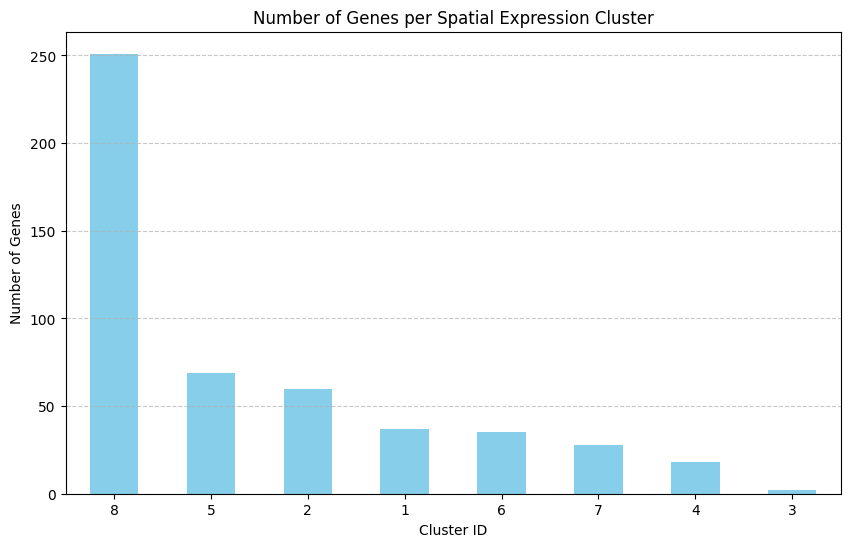

In [14]:
# Visualize the distribution as a bar plot
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Genes per Spatial Expression Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Genes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.4 Visualizing Gene Expression Patterns for Specific Clusters

Now, let's examine the expression patterns of genes in specific clusters. This allows us to see the detailed spatial expression trends for groups of functionally related genes.

<Figure size 1000x1200 with 0 Axes>

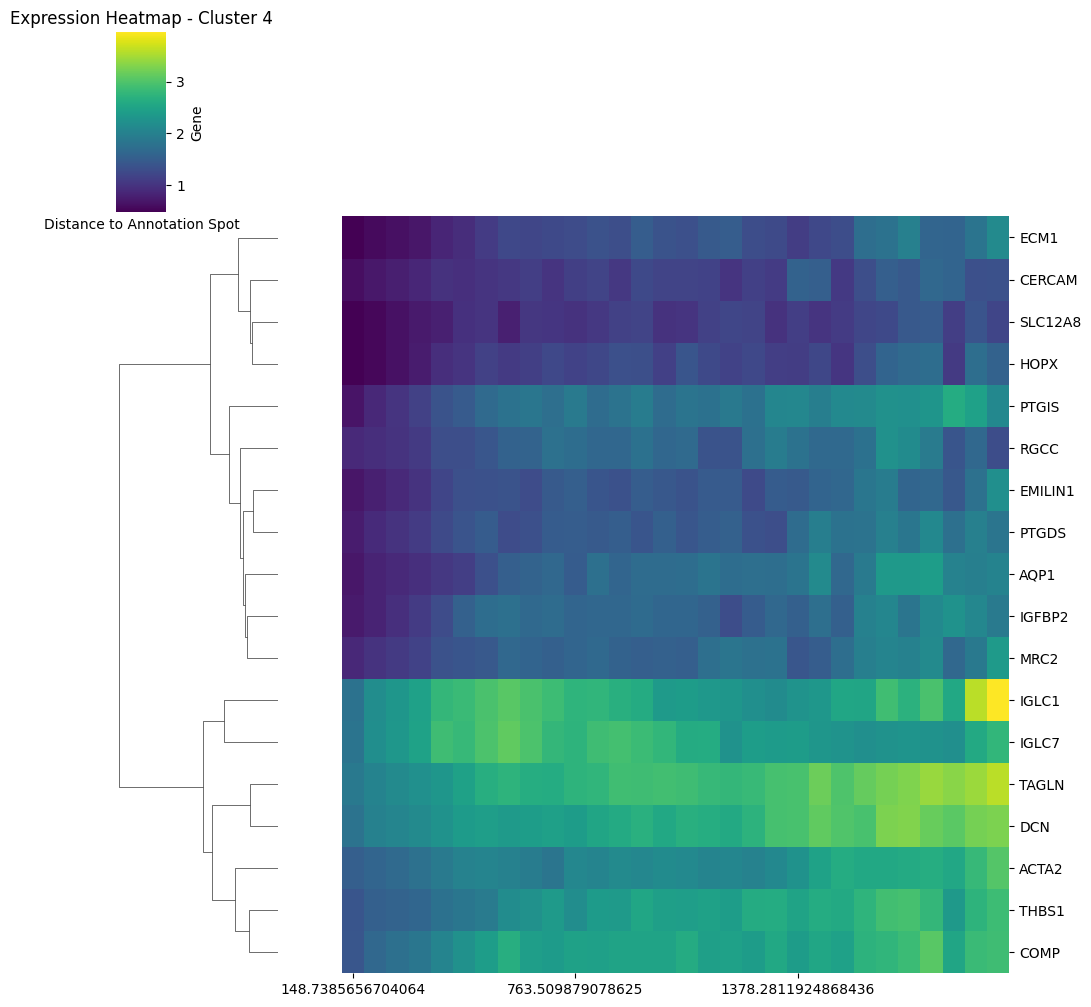

In [15]:
# Visualize genes in cluster 4 relative to distance from tumor
# Parameters explained:
# - cluster_id: Which cluster to visualize
# - distance_col: Which distance column to use
# - bins: Number of distance bins to create
# - interpolate: Whether to use interpolation for smoother visualization
# - max_distance: Maximum distance to consider (None = all distances)
# - smooth: Smoothing factor for the heatmap (higher = smoother)

hm.plot_cluster_expression_distance_heatmap(histomap, 
                                           cluster_df, 
                                           cluster_id=4, 
                                           distance_col="distance_to_Tumor", 
                                           bins=30, 
                                           interpolate=True, 
                                           max_distance=None, 
                                           smooth=0.5)

Let's look at another cluster with a different expression pattern, focusing on a specific distance range to see more detail.

In [ ]:
# Visualize genes in cluster 6 with a limited distance range and more smoothing
hm.plot_cluster_expression_distance_heatmap(histomap, 
                                           cluster_df, 
                                           cluster_id=6, 
                                           distance_col="distance_to_Tumor", 
                                           bins=30, 
                                           interpolate=True, 
                                           max_distance=1000,  # Limit to 1000 microns from tumor
                                           smooth=1,  # More smoothing
                                           title="Expression Pattern of Cluster 6 Genes by Distance from Tumor (Limited Range)")

## 4. Analyzing Tissue Interfaces

Tissue interfaces, such as the boundary between tumor and stroma, are often biologically significant regions where important cellular interactions occur. In this section, we'll identify and analyze these interface regions.

### 4.1 Identifying Interface Regions

First, let's identify spots that are near the interface between tumor and stroma regions. We'll define interface spots as those within a certain distance threshold from both annotations.

In [ ]:
# Define a function to identify interface regions between two annotations
def identify_interface_spots(histomap, annotation1, annotation2, threshold_distance=100):
    """Identify spots at the interface between two annotations.
    
    Parameters:
    -----------
    histomap : HistoMap object
        The HistoMap object with calculated distances
    annotation1, annotation2 : str
        Names of the two annotations to find interfaces between
    threshold_distance : float
        Maximum distance (in microns) from both annotations to be considered an interface spot
        
    Returns:
    --------
    interface_mask : numpy.ndarray
        Boolean mask of spots that are at the interface
    """
    # Make sure distances are calculated for both annotations
    dist_col1 = f'distance_to_{annotation1}'
    dist_col2 = f'distance_to_{annotation2}'
    
    if dist_col1 not in histomap.spot_metadata.columns:
        hm.compute_nearest_annotation_distance(histomap, annotation1)
    if dist_col2 not in histomap.spot_metadata.columns:
        hm.compute_nearest_annotation_distance(histomap, annotation2)
    
    # Create a mask for spots that are near both annotations
    interface_mask = (histomap.spot_metadata[dist_col1] <= threshold_distance) & \
                     (histomap.spot_metadata[dist_col2] <= threshold_distance)
    
    # Add this as a new column in the metadata
    interface_name = f'{annotation1}_{annotation2}_interface'
    histomap.spot_metadata[interface_name] = interface_mask
    
    print(f"Identified {interface_mask.sum()} spots at the {annotation1}-{annotation2} interface")
    
    return interface_mask

In [ ]:
# Identify spots at the tumor-stroma interface
interface_mask = identify_interface_spots(histomap, 'Tumor', 'Stroma', threshold_distance=100)

### 4.2 Visualizing Interface Regions

Now, let's visualize these interface regions on the tissue image.

In [ ]:
# Function to plot interface regions
def plot_interface_regions(histomap, interface_column, title=None, spot_size=70):
    """Plot interface regions on the tissue image.
    
    Parameters:
    -----------
    histomap : HistoMap object
        The HistoMap object with interface information
    interface_column : str
        Name of the column in spot_metadata that contains interface information
    title : str, optional
        Title for the plot
    spot_size : float, optional
        Size of the spots in the plot
    """
    # Get spot coordinates
    spot_x = histomap.spot_metadata['x'].values
    spot_y = histomap.spot_metadata['y'].values
    
    # Create the figure
    plt.figure(figsize=(12, 10))
    
    # Plot the tissue image if available
    if hasattr(histomap, 'image') and histomap.image is not None:
        plt.imshow(histomap.image, cmap='gray', alpha=0.7)
    
    # Plot all spots in light gray
    plt.scatter(spot_x, spot_y, c='lightgray', s=spot_size, alpha=0.5)
    
    # Highlight interface spots in red
    interface_mask = histomap.spot_metadata[interface_column].values
    plt.scatter(spot_x[interface_mask], spot_y[interface_mask], c='red', s=spot_size, alpha=0.8)
    
    # Add title and labels
    if title is None:
        title = f"Spots at {interface_column.replace('_', '-')}"
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot the tumor-stroma interface regions
plot_interface_regions(histomap, 'Tumor_Stroma_interface', 
                      title="Spots at the Tumor-Stroma Interface (≤100μm from both regions)")

### 4.3 Differential Expression Analysis at Interfaces

Now, let's identify genes that are differentially expressed at the tumor-stroma interface compared to the tumor and stroma regions themselves. This can reveal genes involved in tumor-stroma interactions.

In [ ]:
# Convert HistoMap to AnnData for differential expression analysis
import scanpy as sc

# Set standard plotting parameters
sc.settings.set_figure_params(dpi=100, figsize=(8, 8))

# Convert to AnnData
adata = histomap.to_anndata()

# Add interface information to the AnnData object
adata.obs['Tumor_Stroma_interface'] = histomap.spot_metadata['Tumor_Stroma_interface'].values

# Preprocess the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Create a new categorical variable for regions
region_categories = adata.obs['Annotation_map'].copy()
region_categories[adata.obs['Tumor_Stroma_interface']] = 'Interface'
adata.obs['Region_with_interface'] = region_categories

# Filter to include only Tumor, Stroma, and Interface regions
mask = adata.obs['Region_with_interface'].isin(['Tumor', 'Stroma', 'Interface'])
adata_filtered = adata[mask].copy()

In [ ]:
# Perform differential expression analysis
sc.tl.rank_genes_groups(adata_filtered, 'Region_with_interface', method='wilcoxon')

# Visualize the top differentially expressed genes
sc.pl.rank_genes_groups_dotplot(adata_filtered, 
                               groupby='Region_with_interface', 
                               n_genes=5,
                               standard_scale='var',
                               title="Top Genes Differentially Expressed at Tumor-Stroma Interface")

### 4.4 Interface Enrichment Analysis

To gain functional insights, let's see which biological pathways are enriched in genes upregulated at the tumor-stroma interface. This can reveal cellular processes that are active in these interaction zones.

In [ ]:
# Extract genes upregulated at the interface compared to both tumor and stroma
def get_interface_genes(adata, pval_threshold=0.05, log2fc_threshold=0.25):
    """Extract genes upregulated at the interface."""
    # Get results from differential expression analysis
    results = sc.get.rank_genes_groups_df(adata, group='Interface')
    
    # Filter for genes significantly upregulated vs. Tumor
    vs_tumor = results[results['comparison'] == 'Interface vs Tumor']
    tumor_up = vs_tumor[(vs_tumor['pvals_adj'] < pval_threshold) & 
                         (vs_tumor['logfoldchanges'] > log2fc_threshold)]
    
    # Filter for genes significantly upregulated vs. Stroma
    vs_stroma = results[results['comparison'] == 'Interface vs Stroma']
    stroma_up = vs_stroma[(vs_stroma['pvals_adj'] < pval_threshold) & 
                          (vs_stroma['logfoldchanges'] > log2fc_threshold)]
    
    # Get genes upregulated in both comparisons
    common_genes = set(tumor_up['names']).intersection(set(stroma_up['names']))
    
    print(f"Found {len(common_genes)} genes upregulated at the interface compared to both tumor and stroma regions")
    
    return list(common_genes)

In [ ]:
# This is a placeholder for pathway enrichment analysis
# In a real workflow, you would use tools like gseapy, gprofiler, or enrichr to perform enrichment analysis
# For example:

'''
import gseapy as gp

# Get interface genes
interface_genes = get_interface_genes(adata_filtered)

# Perform enrichment analysis
enrichr_results = gp.enrichr(gene_list=interface_genes,
                            gene_sets=['GO_Biological_Process_2021'],
                            organism='Human',
                            outdir='enrichr_output',
                            cutoff=0.05)

# Plot results
enrichr_results.plot("barplot", title="Pathways Enriched at Tumor-Stroma Interface")
'''

## 5. Cell-Cell Communication Analysis

Another powerful application of spatial transcriptomics is the inference of potential cell-cell communication based on spatial proximity and the expression of receptor-ligand pairs. Here, we'll demonstrate how to use the CellChatDB database to identify potential communication channels between different tissue regions.

In [ ]:
# This is a placeholder for cell-cell communication analysis
# In a real workflow, you might use packages like squidpy, cell2location, or CellChat for R

'''
import squidpy as sq

# Calculate spatial neighbors
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

# Calculate ligand-receptor interactions
sq.gr.ligrec(adata, n_perms=100, cluster_key="Annotation_map")

# Plot interactions
sq.pl.ligrec_rank(adata, cluster_key="Annotation_map", source_groups=["Tumor"], target_groups=["Stroma"])
'''

## 6. Spatial Transcriptomics Integration with Other Data Types

Spatial transcriptomics data can be integrated with other data types, such as single-cell RNA-seq, proteomics, or clinical data. Here, we'll demonstrate a simple deconvolution approach to estimate cell type proportions in each Visium spot.

In [ ]:
# This is a placeholder for cell type deconvolution
# In a real workflow, you might use packages like cell2location, SPOTlight, or RCTD

'''
# Example with SPOTlight (using reticulate to access the R package from Python)
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

# Load R packages
ro.r('library(SPOTlight)')
ro.r('library(Seurat)')

# Load reference single-cell data (this would be your own scRNA-seq data)
ro.r('scRNA <- readRDS("reference_scRNA.rds")')

# Convert AnnData to Seurat
# ...

# Run SPOTlight deconvolution
ro.r('deconv_res <- spotlight_deconvolution(seurat_obj, scRNA, cluster_col = "celltype")')

# Visualize results
ro.r('SpatialFeaturePlot(seurat_obj, features = c("T_cells", "B_cells", "Fibroblasts"))')
'''

## 7. Conclusions and Next Steps

In this tutorial, we've explored advanced analysis techniques for spatial transcriptomics data with HistoMapTx, focusing on leveraging tissue annotations to gain biological insights. We've covered:

1. **Spatial Distance Analysis**: Calculating and visualizing distances from specific tissue regions
2. **Expression Gradients**: Analyzing how gene expression changes with distance from specific regions
3. **Gene Pattern Identification**: Clustering genes based on their spatial expression patterns
4. **Interface Analysis**: Identifying and characterizing tissue interface regions
5. **Differential Expression**: Finding genes that are specifically expressed at tissue boundaries

### Biological Significance

The analyses we've performed can reveal important biological processes:

- Gradients of signaling molecules extending from tumor borders
- Immunological exclusion or infiltration patterns
- Tumor-stroma interactions and communication
- Spatial organization of the tumor microenvironment
- Cellular heterogeneity and niche-specific gene expression

### Next Steps

To further extend this analysis, consider:

1. **Integration with scRNA-seq**: Use cell type deconvolution to estimate cell type proportions in each spot
2. **Spatial Statistics**: Apply spatial autocorrelation and clustering techniques
3. **Multimodal Integration**: Combine with immunohistochemistry or multiplexed protein data
4. **Cross-Sample Analysis**: Compare spatial patterns across multiple tissue samples
5. **Pathway Analysis**: Perform spatial pathway enrichment to identify region-specific biological processes
6. **Machine Learning**: Apply deep learning for spatial pattern recognition and prediction

### Further Resources

- **HistoMapTx Documentation**: [link to documentation]
- **Spatial Transcriptomics Reviews**: [Rao et al. 2021](https://www.nature.com/articles/s41576-021-00465-2)
- **Complementary Tools**: Squidpy, Giotto, STUtility
- **Advanced Visualization**: Napari, VitessceR

The field of spatial transcriptomics is rapidly evolving, offering exciting opportunities to uncover the spatial architecture of gene expression in complex tissues and disease states.